In [41]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma', 'filippiny'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма
Филиппины


In [42]:
len(country_name_rus.keys())

85

In [43]:
stemming=False # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [44]:
from stop_words_ru import ru_stopwords

In [45]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [46]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [47]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_29-01-2025.json')     
    df = pd.read_json('Country_DB_V4_29-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_25-08-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_25-08-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [48]:
df_checked

,country,text
0,Судан,судане сезонных наводнений пострадало тысяч че...
1,Судан,срыв американо суданских переговоров каире пер...
10,Турция,глава суверенного совета судана встретился пре...
100,Ирак,президент ирана масуд пезешкиан правительствен...
1000,КНР,китайские технологии обеспечивают работу интел...
...,...,...
995,Кения,африканская опера концертов классической музык...
996,Эфиопия,эфиопской школе джаза джаз музыкальное направл...
997,Кения,бёрдером кении называют любителей птиц фотогра...
998,КНР,торги фондовых биржах китая завершились ростом...


In [49]:
df

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
9995,Руанда,сми руанда обвинила конго причастности похищен...
9996,Руанда,африканский союз выразил беспокойство кризисом...
9997,Руанда,церковь англии раскритиковала планы правительс...
9998,Руанда,трасс подтвердила британия начнет отправлять н...


In [50]:
len(set(MergeJson["country"].tolist()))

85

In [51]:
from tabulate import tabulate
data =[]
for country in set(MergeJson["country"].tolist()):    
    data.append([country, MergeJson[MergeJson["country"]==country]['text'].count(), df[df["country"]==country]['text'].count(), df_checked[df_checked["country"]==country]['text'].count()])    
print(tabulate(data, headers=[' общая БД', 'старая БД', 'проверенная БД']))

                                      общая БД    старая БД    проверенная БД
---------------------------------  -----------  -----------  ----------------
КНР                                       2472         2212               260
Гана                                       249          205                44
Республика Конго                           214          201                13
Камбоджа                                    78           68                10
Индонезия                                  191           89               102
Таиланд                                    145           73                72
Беларусь                                   235          209                26
Сирия                                      149           82                67
Саудовская Аравия                          226          206                20
Монголия                                   127           82                45
Нигерия                                    275          185     

In [52]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

X_df = np.array(df['text'], dtype=object)
y_df = np.array(df['country'])

X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size=0.3, random_state=42)

In [53]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

X_df_checked = np.array(df_checked['text'], dtype=object)
y_df_checked = np.array(df_checked['country'])

X_train_df_checked, X_test_df_checked, y_train_df_checked, y_test_df_checked = train_test_split(X_df_checked, y_df_checked, test_size=0.3, random_state=42)

In [54]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [55]:
len(X)

26092

In [56]:
len(y)

26092

In [57]:
MergeJson

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
995,Кения,африканская опера концертов классической музык...
996,Эфиопия,эфиопской школе джаза джаз музыкальное направл...
997,Кения,бёрдером кении называют любителей птиц фотогра...
998,КНР,торги фондовых биржах китая завершились ростом...


In [58]:
from tabulate import tabulate
score_data = []

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed_df = tfidf.fit_transform(X_train_df)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_df = DecisionTreeClassifier()
rf_df.fit(X_train_transformed_df, y_train_df)

y_pred_df = rf_df.predict_proba(X_train_transformed_df)[:, 1]
score_df = cross_val_score(rf_df, X_train_transformed_df, y_train_df, cv=3, verbose=3)
print(score_df.mean())
print(cross_val_score(rf_df, X_train_transformed_df, y_train_df, scoring='accuracy'))
print(cross_val_score(rf_df, X_train_transformed_df, y_train_df, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.776) total time=  12.1s
[CV] END ................................ score: (test=0.763) total time=  12.1s
[CV] END ................................ score: (test=0.765) total time=  11.6s
0.7680236029102431
[0.77248141 0.77612445 0.76766994 0.76327359 0.7700372 ]
[0.74582145 0.73968494 0.73306423 0.73067565 0.74098211]


In [60]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df = tfidf.transform(X_test_df)

rf_df.fit(X_test_transformed_df, y_test_df)

y_pred_df = rf_df.predict(X_test_transformed_df)

score_data.append(['DecisionTreeClassifier (old BD)', "{:.2f}".format(100 * score_df.mean()),
              "{:.2f}".format(100 * precision_score(y_test_df, y_pred_df, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df, y_pred_df, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                    Precision (train), %     Precision(test), %    Recall(test), %
-------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                     76.8                   98.4              98.26


In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed = tfidf.fit_transform(X_train)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf = DecisionTreeClassifier()
rf.fit(X_train_transformed, y_train)

y_pred = rf.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf, X_train_transformed, y_train, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.770) total time=  16.1s
[CV] END ................................ score: (test=0.773) total time=  15.8s
[CV] END ................................ score: (test=0.767) total time=  15.4s
0.7700941743320193
[0.7716945  0.7774432  0.78291815 0.77224199 0.7694414 ]
[0.73238732 0.73349134 0.74317218 0.73363694 0.74192747]


In [62]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf.fit(X_test_transformed, y_test)

y_pred = rf.predict(X_test_transformed)

score_data.append(['DecisionTreeClassifier (all BD)', "{:.2f}".format(100 * score.mean()),
              "{:.2f}".format(100 * precision_score(y_test, y_pred, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test, y_pred, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                    Precision (train), %     Precision(test), %    Recall(test), %
-------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                    76.8                   98.4               98.26
DecisionTreeClassifier (all BD)                    77.01                  98.67              98.58


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer





tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed_df_checked = tfidf.fit_transform(X_train_df_checked)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_df_checked = DecisionTreeClassifier()
rf_df_checked.fit(X_train_transformed_df_checked, y_train_df_checked)

y_pred_df_checked = rf_df_checked.predict_proba(X_train_transformed_df_checked)[:, 1]
score = cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='accuracy'))
print(cross_val_score(rf_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.742) total time=   1.7s
[CV] END ................................ score: (test=0.750) total time=   1.6s
[CV] END ................................ score: (test=0.744) total time=   1.6s
0.7452567611793758


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.74712644 0.77586207 0.76149425 0.75971223 0.74676259]


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.61771436 0.62938622 0.65119339 0.63511021 0.62509766]


In [64]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df_checked = tfidf.transform(X_test_df_checked)

rf_df_checked.fit(X_test_transformed_df_checked, y_test_df_checked)

y_pred_df_checked = rf_df_checked.predict(X_test_transformed_df_checked)

score_data.append(['DecisionTreeClassifier (checked BD)', "{:.2f}".format(100 * score.mean()),
              "{:.2f}".format(100 * precision_score(y_test_df_checked, y_pred_df_checked, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df_checked, y_pred_df_checked, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        76.8                   98.4               98.26
DecisionTreeClassifier (all BD)                        77.01                  98.67              98.58
DecisionTreeClassifier (checked BD)                    74.53                  99.93              99.93


In [65]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_DecisionTreeClassifier_tfidf_V4_024_{}_lowRAM_nostamm_NEW.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf, tfidf.get_feature_names_out()], f_out)

In [66]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed_df = tfidf.fit_transform(X_train_df)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest_df = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest_df.fit(X_train_transformed_df, y_train_df)

y_pred_df = rf_RandomForest_df.predict_proba(X_train_transformed_df)[:, 1]
score = cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, scoring='accuracy'))
print(cross_val_score(rf_RandomForest_df, X_train_transformed_df, y_train_df, scoring='f1_macro')) 
print(rf_RandomForest_df.oob_score_)

[CV] END ................................ score: (test=0.842) total time=   1.9s
[CV] END ................................ score: (test=0.840) total time=   1.8s
[CV] END ................................ score: (test=0.839) total time=   1.6s
0.840254215377846
[0.84956051 0.83226243 0.83699696 0.83834968 0.84376057]
[0.82576001 0.80635387 0.80915782 0.81106048 0.81955408]
0.8328824563776546


In [67]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df = tfidf.transform(X_test_df)

rf_RandomForest_df.fit(X_test_transformed_df, y_test_df)

y_pred_RandomForest_df = rf_RandomForest_df.predict(X_test_transformed_df)


score_data.append(['RandomForestClassifier (old BD)', "{:.2f}".format(100 * rf_RandomForest_df.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test_df, y_pred_RandomForest_df, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df, y_pred_RandomForest_df, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        76.8                   98.4               98.26
DecisionTreeClassifier (all BD)                        77.01                  98.67              98.58
DecisionTreeClassifier (checked BD)                    74.53                  99.93              99.93
RandomForestClassifier (old BD)                        82.77                  95.68              95.19


In [68]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.842) total time=   2.0s
[CV] END ................................ score: (test=0.844) total time=   2.0s
[CV] END ................................ score: (test=0.842) total time=   2.0s
0.8430792816469558
[0.83684643 0.85354503 0.84423761 0.84314262 0.85268346]
[0.81507406 0.83404976 0.81953231 0.81910833 0.83118327]
0.8394108628996934


In [69]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

score_data.append(['RandomForestClassifier (all BD)', "{:.2f}".format(100 * rf_RandomForest.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        76.8                   98.4               98.26
DecisionTreeClassifier (all BD)                        77.01                  98.67              98.58
DecisionTreeClassifier (checked BD)                    74.53                  99.93              99.93
RandomForestClassifier (old BD)                        82.77                  95.68              95.19
RandomForestClassifier (all BD)                        83.27                  95.77              94.97


In [70]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_024_{}_lowRAM_nostamm.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf.get_feature_names_out()], f_out)

In [71]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed_df_checked = tfidf.fit_transform(X_train_df_checked)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest_df_checked = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest_df_checked.fit(X_train_transformed_df_checked, y_train_df_checked)

y_pred_df_checked = rf_RandomForest_df_checked.predict_proba(X_train_transformed_df_checked)[:, 1]
score = cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='accuracy'))
print(cross_val_score(rf_RandomForest_df_checked, X_train_transformed_df_checked, y_train_df_checked, scoring='f1_macro')) 
print(rf_RandomForest_df_checked.oob_score_)

[CV] END ................................ score: (test=0.817) total time=   0.3s
[CV] END ................................ score: (test=0.818) total time=   0.3s
[CV] END ................................ score: (test=0.809) total time=   0.3s
0.8148354209435403


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.81752874 0.84482759 0.84051724 0.81582734 0.82302158]


D:\ML\ML_env\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[0.72632402 0.79548982 0.75021923 0.73788943 0.75533098]
0.8102357676825762


In [72]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed_df_checked = tfidf.transform(X_test_df_checked)

rf_RandomForest_df_checked.fit(X_test_transformed_df_checked, y_test_df_checked)

y_pred_RandomForest_df_checked = rf_RandomForest_df_checked.predict(X_test_transformed_df_checked)


score_data.append(['RandomForestClassifier (checked BD)', "{:.2f}".format(100 * rf_RandomForest_df_checked.oob_score_),
              "{:.2f}".format(100 * precision_score(y_test_df_checked, y_pred_RandomForest_df_checked, average='weighted')),
            "{:.2f}".format(100 * recall_score(y_test_df_checked, y_pred_RandomForest_df_checked, average='weighted'))])
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

                                        Precision (train), %     Precision(test), %    Recall(test), %
-----------------------------------  -----------------------  ---------------------  -----------------
DecisionTreeClassifier (old BD)                        76.8                   98.4               98.26
DecisionTreeClassifier (all BD)                        77.01                  98.67              98.58
DecisionTreeClassifier (checked BD)                    74.53                  99.93              99.93
RandomForestClassifier (old BD)                        82.77                  95.68              95.19
RandomForestClassifier (all BD)                        83.27                  95.77              94.97
RandomForestClassifier (checked BD)                    79.48                  94.39              93.63


In [73]:
print('Итоговая сводка:')
from tabulate import tabulate
data =[]
score = []
for country in set(MergeJson["country"].tolist()):    
    data.append([country, MergeJson[MergeJson["country"]==country]['text'].count(), df[df["country"]==country]['text'].count(), df_checked[df_checked["country"]==country]['text'].count()])    
print(tabulate(data, headers=[' общая БД', 'старая БД', 'проверенная БД']))
print(tabulate(score_data, headers=[' Precision (train), %',' Precision(test), %', 'Recall(test), %']))

Итоговая сводка:
                                      общая БД    старая БД    проверенная БД
---------------------------------  -----------  -----------  ----------------
КНР                                       2472         2212               260
Гана                                       249          205                44
Республика Конго                           214          201                13
Камбоджа                                    78           68                10
Индонезия                                  191           89               102
Таиланд                                    145           73                72
Беларусь                                   235          209                26
Сирия                                      149           82                67
Саудовская Аравия                          226          206                20
Монголия                                   127           82                45
Нигерия                                    275 

In [74]:
impoгtances = rf_RandomForest_df_checked.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

              Word  Importance
3720          мали    0.007824
3609         ливии    0.006989
9908           юар    0.006937
3319         конго    0.006826
2472        замбии    0.006778
3167         кении    0.006771
2638      зимбабве    0.006663
4635       нигерии    0.006322
640        бурунди    0.005977
3744       марокко    0.005736
7729      сенегала    0.005695
556        боливии    0.005648
8955        турции    0.005524
1468        гвинеи    0.005442
405      бангладеш    0.005427
4240        мьянмы    0.005358
3016      источник    0.005221
638   буркина фасо    0.005117
222         алжира    0.005072
600       бразилии    0.005044
9034        уганды    0.004966
8649      танзании    0.004943
5568          перу    0.004582
3457           кот    0.004461
302      аргентины    0.004422
9348          фасо    0.004381
9373      филиппин    0.004296
348    афганистана    0.004209
3271      колумбии    0.004202
2934         ирана    0.004191
3458     кот ивуар    0.004181
3531    

In [75]:
with open('./datasets/feature_importances_nostamm.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

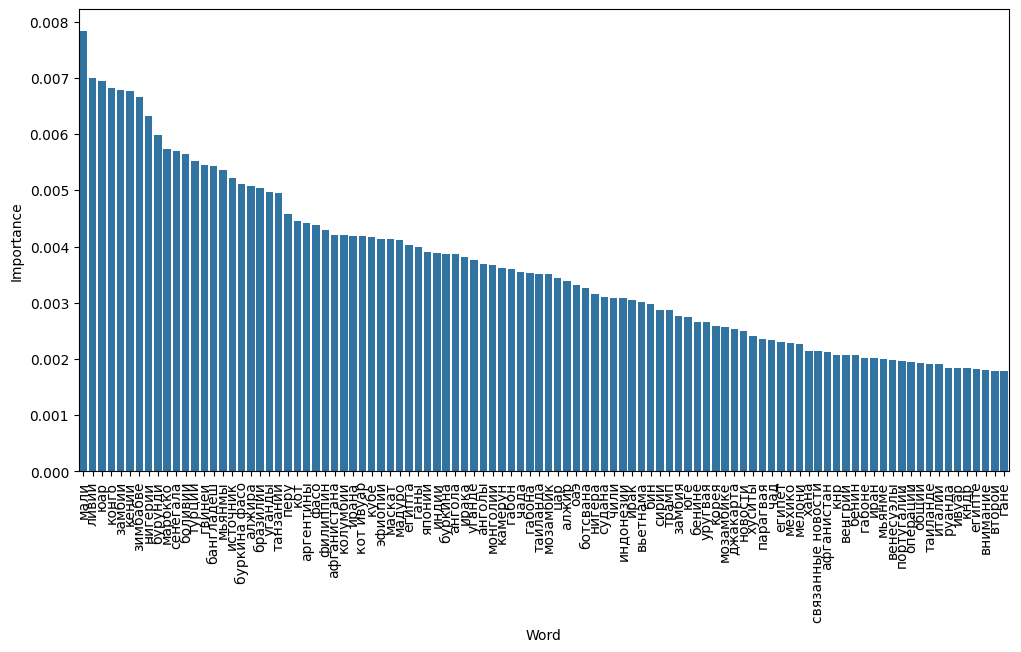

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [77]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Почему слова Трампа о присоединении Гренландии надо воспринимать всерьёз — статья Максима Сучкова @postamerica: • Присоединение территорий — обычный способ наращивания государствами мощи. Для лидеров — это ещё и возможность запомниться потомкам, войти в историю. Эгоцентрист-государственник Трамп желает и первого, и второго. Как политик-националист, он стремится укрепить американские позиции в «ближнем зарубежье» США. Как «политик на втором сроке», он хочет, чтобы каждое решение по этой части было стратегическим и долгосрочным, «оставляло наследие». А специфический образ мысли Трампа требует, чтобы это наследие обязательно было грандиозным. • В случае с заявлениями Трампа по поводу Гренландии партнёры Америки находятся в замешательстве: зачем забирать земли у союзников, да ещё в тот момент, когда они третий год подряд убеждают мир в том, что так нельзя и за это надо наказывать? Особенно негодуют французы и датчане, по иронии судьбы, некогда продавшие Соединённым Штатам свои заморские территории: французы — Луизиану в 1803 году (за $15 млн), датчане — Датскую Вест-Индию (современные Американские Виргинские Острова) в 1917 году (за $25 млн). • Трампа, очевидно, не сильно заботит эта реакция. Но ему, вероятно, хочется, чтобы процедура присоединения острова была оформлена красиво — с соблюдением внешних приличий и юридических правил. Провернуть всё это американцам вполне по силам: нация коммерсантов и юристов, по части способности покупать, продавать и обрамлять это изысканной правовой рамкой, равных себе не имеет. • Судя по всему, Трамп нацелен именно на этот сценарий: Трамп-младший слетал в Гренландию, где, по слухам, прощупывал местные лояльные Америке круги, выясняя их готовность организовать референдум о вхождении в состав США; республиканские законодатели в Конгрессе изучают варианты правового оформления этой инициативы; экономисты рассчитывают стоимость возможной сделки — она варьируется в диапазоне от $12,5 млрд до $77 млрд. Параллельно прорабатывается и вариант с долгосрочной арендой острова. • С середины XIX века Гренландия рассматривается США как ключ к контролю над Арктикой. Сегодня Арктика — одна из главных арен великодержавного соперничества. Традиционный инструментарий усиления в этом регионе самих американцев — виртуозно использовать нормотворчество, регламентирующее пользование Арктикой, и стремиться увеличивать площади континентального шельфа. Это они делали задолго до Трампа. • Сам же Трамп убеждён: в то время как конкуренты США укреплялись, Байден и его команда на протяжении четырёх лет только и делали, что бездумно расточали ресурсы страны. Пришла пора собирать камни. Читать статью для @profilejournal'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
count = CountVectorizer(ngram_range=(1,5), vocabulary = set(tfidf.get_feature_names_out()))
#count = CountVectorizer(vocabulary = set(X_train_words))
X_t = count.transform(x_temp)
#print(count.vocabulary_)
accuracy = rf_RandomForest_df_checked.predict(X_t)
print (accuracy)

['Мали' 'Индонезия' 'КНР' 'Бангладеш' 'Венесуэла' 'Бразилия' 'США']


In [78]:
probabilities = rf_RandomForest_df_checked.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest_df_checked.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest_df_checked.classes_):
        if probabilities[i][ix]>0.02:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Ирак, Probability = 0.03
 Class Испания, Probability = 0.03
 Class Мали, Probability = 0.39
 Class Нигер, Probability = 0.05
 Class Португалия, Probability = 0.03
 Class Сенегал, Probability = 0.29
Sample 1
 Class Аргентина, Probability = 0.03
 Class Бангладеш, Probability = 0.02
 Class Вьетнам, Probability = 0.05
 Class Индия, Probability = 0.02
 Class Индонезия, Probability = 0.13
 Class КНДР, Probability = 0.02
 Class КНР, Probability = 0.02
 Class Лаос, Probability = 0.04
 Class Мали, Probability = 0.03
 Class Морокко, Probability = 0.02
 Class Португалия, Probability = 0.04
 Class Сирия, Probability = 0.03
 Class Центрально-Африканская Республика, Probability = 0.02
 Class Чад, Probability = 0.02
 Class Эфиопия , Probability = 0.02
 Class Япония, Probability = 0.03
Sample 2
 Class Афганистан, Probability = 0.02
 Class Индия, Probability = 0.03
 Class КНДР, Probability = 0.02
 Class КНР, Probability = 0.23
 Class Лаос, Probability = 0.03
 Class Мексика, Probability 

In [79]:
rf_RandomForest.classes_

array(['Алжир', 'Ангола', 'Аргентина', 'Афганистан', 'Бангладеш',
       'Беларусь', 'Бенин', 'Боливия', 'Ботсвана', 'Бразилия',
       'Буркина-Фасо', 'Бурунди', 'Венгрия', 'Венесуэла', 'Вьетнам',
       'Габон', 'Гана', 'Гвинея', 'Германия', 'ДРК (Конго)', 'Египет',
       'Замбия', 'Зимбабве', 'Израиль', 'Индия', 'Индонезия', 'Иордания',
       'Ирак', 'Иран', 'Испания', 'Италия', 'Йемен', 'КНДР', 'КНР',
       'КНР (Тайвань)', 'Камбоджа', 'Камерун', 'Кения', 'Колумбия',
       "Кот-д'Ивуар", 'Куба', 'Лаос', 'Ливан', 'Ливия', 'Литва',
       'Мадагаскар', 'Мали', 'Мексика', 'Мозамбик', 'Монголия', 'Морокко',
       'Мьянма', 'Намибия', 'Нигер', 'Нигерия', 'ОАЭ', 'Оман', 'Пакистан',
       'Палестина', 'Парагвай', 'Перу', 'Португалия', 'Республика Конго',
       'Руанда', 'США', 'Саудовская Аравия', 'Сенегал', 'Сирия', 'Судан',
       'Таиланд', 'Танзания', 'Тунис', 'Турция', 'Уганда', 'Уругвай',
       'Филиппины', 'Франция', 'Центрально-Африканская Республика', 'Чад',
       'Чили'

In [80]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_024_{}_lowRAM_nostamm_NEW.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest_df_checked, tfidf.get_feature_names_out()], f_out)